# FER Experiments
### Datasets
- FER2013
- CK+
- AffectNet
- RF-DB

In [1]:
import random
import tensorflow as tf
import numpy as np

SEED = 8

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)


2026-01-20 20:37:56.677559: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import os, sys
module_path = os.path.abspath(os.path.join('..', '..')) 
sys.path.insert(0, module_path)
from src.data_loading import load_rafbd, load_ck, load_fer2013, load_affectnet, load_meld, filter_emotions, load_iemocap
from src.evaluation import plot_confusion_matrix, plot_training_history
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from keras.models import load_model
from PIL import Image
import cv2


def split_dataset_train_val_test(df, val_size=0.2, test_size=0.3, seed=SEED):
    train_val_df, test_df = train_test_split(df, test_size=test_size, random_state=seed, stratify=df['label'])
    train_df, val_df = train_test_split(train_val_df, test_size=val_size/(1 - test_size), random_state=seed, stratify=train_val_df['label'])
    return train_df, val_df, test_df

def preprocess_fer_row(pixels_str, target_size=(48, 48)):
    # Convert string of space-separated pixel values to 2D image
    pixels = np.fromstring(pixels_str, sep=' ', dtype=np.uint8)
    pixels = pixels.reshape(target_size)
    # Convert to float, normalize, and expand dims
    pixels = pixels.astype("float32") / 255.0
    pixels = np.expand_dims(pixels, axis=-1)
    return pixels

def preprocess_raf_row(filename):
    # read and convert image to grayscale
    image = Image.open(filename).convert('L')
    image = image.resize((48, 48))
    np_image = np.array(image).astype("float32") / 255.0
    np_image = np.expand_dims(np_image, axis=-1)
    return np_image


ck = filter_emotions(load_ck())
fer = filter_emotions(load_fer2013())
raf = filter_emotions(load_rafbd())
affect = filter_emotions(load_affectnet())

ck["pixels"] = ck["pixels"].apply(preprocess_fer_row)
fer["pixels"] = fer["pixels"].apply(preprocess_fer_row)
raf["pixels"] = raf["filename"].apply(preprocess_raf_row)
affect["pixels"] = affect["filename"].apply(preprocess_raf_row)

cols = ['pixels', 'label']
ck, fer, raf, affect = ck[cols], fer[cols], raf[cols], affect[cols]


ck_train, ck_val, ck_test = split_dataset_train_val_test(ck)
raf_train, raf_val, raf_test = split_dataset_train_val_test(raf)
affect_train, affect_val, affect_test = split_dataset_train_val_test(affect)
fer_train, fer_val, fer_test = split_dataset_train_val_test(fer)

Subfolders in the dataset: ['ckextended.csv']
Subfolders in the dataset: ['fer2013.csv']


100%|██████████| 3068/3068 [00:02<00:00, 1303.10it/s]


Dataset downloaded to: /Users/sofiafernandes/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1
Available folders: ['happy', 'Contempt', 'sad', 'fear', 'surprise', 'neutral', 'Anger', 'disgust']


100%|██████████| 8/8 [00:14<00:00,  1.85s/it]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from fer_cnn_utils import preprocess_frame, build_light_cnn
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam


def build_light_cnn(input_shape=(48, 48, 1), num_classes=7):
    """
    Lightweight CNN for emotion recognition from frames.
    """
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(256, (3,3), activation='relu', padding='same',),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dropout(0.7),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    
    

    optimizer = Adam(learning_rate=3e-4)
    model.compile(optimizer=optimizer, #'adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model



# FER2013 + RAF-DB

In [ ]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, raf_train])
df_val = pd.concat([fer_val, raf_val])
df_test = ck
#df_test = affect

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

Epoch 1/100
609/609 [==============================] - ETA: 0s - loss: 1.9954 - accuracy: 0.2586
Epoch 1: val_accuracy improved from -inf to 0.33701, saving model to best_cnn_model.h5
609/609 [==============================] - 80s 127ms/step - loss: 1.9954 - accuracy: 0.2586 - val_loss: 1.7010 - val_accuracy: 0.3370 - lr: 3.0000e-04
Epoch 2/100


/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


609/609 [==============================] - ETA: 0s - loss: 1.6327 - accuracy: 0.3631
Epoch 2: val_accuracy improved from 0.33701 to 0.39900, saving model to best_cnn_model.h5
609/609 [==============================] - 74s 122ms/step - loss: 1.6327 - accuracy: 0.3631 - val_loss: 1.5429 - val_accuracy: 0.3990 - lr: 3.0000e-04
Epoch 3/100
609/609 [==============================] - ETA: 0s - loss: 1.5034 - accuracy: 0.4183
Epoch 3: val_accuracy improved from 0.39900 to 0.43493, saving model to best_cnn_model.h5
609/609 [==============================] - 74s 121ms/step - loss: 1.5034 - accuracy: 0.4183 - val_loss: 1.4721 - val_accuracy: 0.4349 - lr: 3.0000e-04
Epoch 4/100
609/609 [==============================] - ETA: 0s - loss: 1.4175 - accuracy: 0.4516
Epoch 4: val_accuracy improved from 0.43493 to 0.47266, saving model to best_cnn_model.h5
609/609 [==============================] - 77s 126ms/step - loss: 1.4175 - accuracy: 0.4516 - val_loss: 1.3569 - val_accuracy: 0.4727 - lr: 3.0000e-0

337/337 [==============================] - 1s 4ms/step
              precision    recall  f1-score   support

       angry       0.52      0.39      0.45      1486
     disgust       0.60      0.24      0.35       164
        fear       0.40      0.38      0.39      1536
       happy       0.73      0.79      0.76      2697
     neutral       0.49      0.55      0.52      1860
         sad       0.43      0.47      0.45      1823
    surprise       0.73      0.69      0.71      1201

    accuracy                           0.56     10767
   macro avg       0.56      0.50      0.52     10767
weighted avg       0.56      0.56      0.56     10767



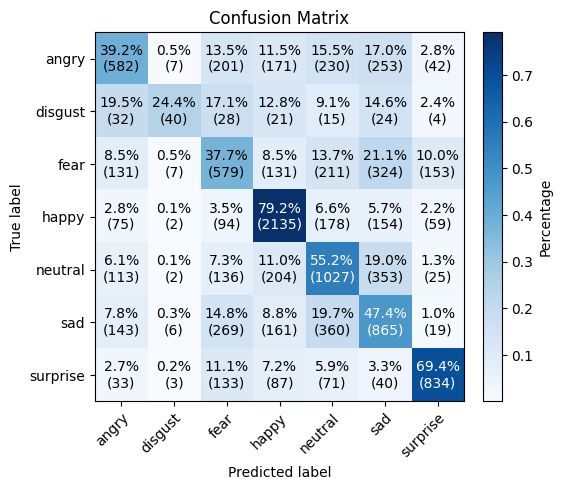

In [ ]:
## CK
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## AffectNet
df_test = affect
X_test  = np.stack(df_test["pixels"].values)
y_test = label_encoder.transform(df_test['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)


### FER2013, RAF-DB, AffectNet

In [ ]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, raf_train, affect_train])
df_val = pd.concat([fer_val, raf_val, affect_val])
df_test = ck
#df_test = affect

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

In [ ]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### FER2013, AffectNet

### RAF-DB, AffectNet

### CK, RAF-DB

### CK, RAF-DB, AffectNet

### CK, AffectNet

### FER2012, CK, AffectNet

### CK, FER2013

### FER2013, RAF-DB, CK+

### FER2013, CK